In [1]:
##This gonna have 
1. Load the data
2. Exploratory data analysis
3. Data pre-processing
4. Using Collaborative filtering (k-nearest neighbors)
5. Cold-start problem with content-based filtering
6. Advanced(Dimensionality reduction with matrix factorization)

# Step 1: Load the data

We are using [pandas.DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) to represent our data. We will visualize our data through [matplotlib](https://matplotlib.org/) and [seaborn](https://seaborn.pydata.org/)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The data we got through is a small version of MovieLens dataset. You can get through [here](https://grouplens.org/datasets/movielens/)



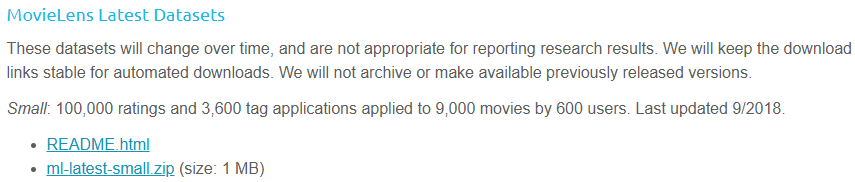

We're working with data in [ml-latest-small.zip(size: 1 MB)](https://grouplens.org/datasets/movielens/) and will need to add the following files to our repository:

- ratings.csv
- movies.csv

In [13]:
ratings = pd.read_csv(r"C:\Users\admin\Desktop\BDS 23 - SYD- SPJAIN\SOPHOMORE YEAR\SEM 2\ML SPJAIN\ml-latest-small\ml-latest-small\ratings.csv")

In [14]:
movies= pd.read_csv(r"C:\Users\admin\Desktop\BDS 23 - SYD- SPJAIN\SOPHOMORE YEAR\SEM 2\ML SPJAIN\ml-latest-small\ml-latest-small\movies.csv")

In [17]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [18]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


# Step 2: EDA

In [37]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
n_users= ratings['userId'].nunique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieID's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user:{round(n_ratings/n_users,2)}") #telling to take round to 2 decimal places
print(f"Average number of ratings per movies:{round(n_ratings/n_movies,2)}")

Number of ratings: 100836
Number of unique movieID's: 9724
Number of unique users: 610
Average number of ratings per user:165.3
Average number of ratings per movies:10.37


**What is distribution of movie ratings?**

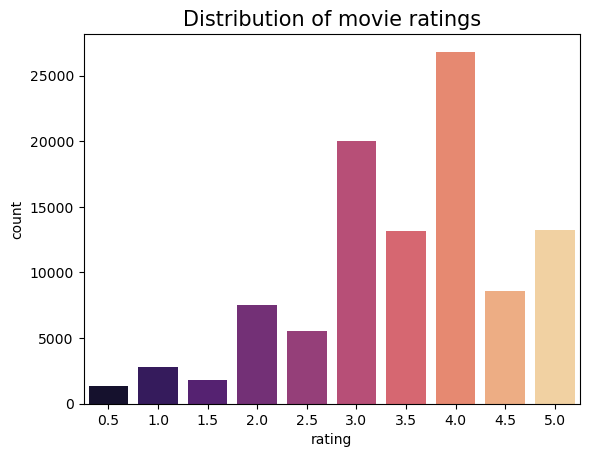

In [56]:
sns.countplot(ratings, x="rating",palette="magma")
plt.title("Distribution of movie ratings", fontsize=15)
plt.show()

In [57]:
print(f"Mean global rating:{round(ratings['rating'].mean(),2)}")

Mean global rating:3.5


In [72]:
mean_ratings= ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}")

Mean rating per user: 3.66


**Which movies are most frequently rated**

In [73]:
movie_ratings = ratings.merge(movies,on='movieId')
movie_ratings['title'].value_counts()[0:10]

Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: title, dtype: int64

Forrest Gump (1994) , Shawshank Redemption(1994) and Pulp Fiction(1994) has the most rating

**What are the lowerst and highest movie rated?**

In [ ]:
mean_rating = ratings.groupby()

In [ ]:
eb

# Step 4: Data Pre-Processing

We are going to use a technique called colaborative filtering to generate recommendations for users. This techniques is based on the premise that similar people like similar things

The first step is to transfrom our data into user-item matrix, also known as a "utility" matrix. In this matrix, rows represent users and collumns represent movies. The beauty of collaborative filtering is that it doesnt require any further information about the users or the movies users to generate informations.


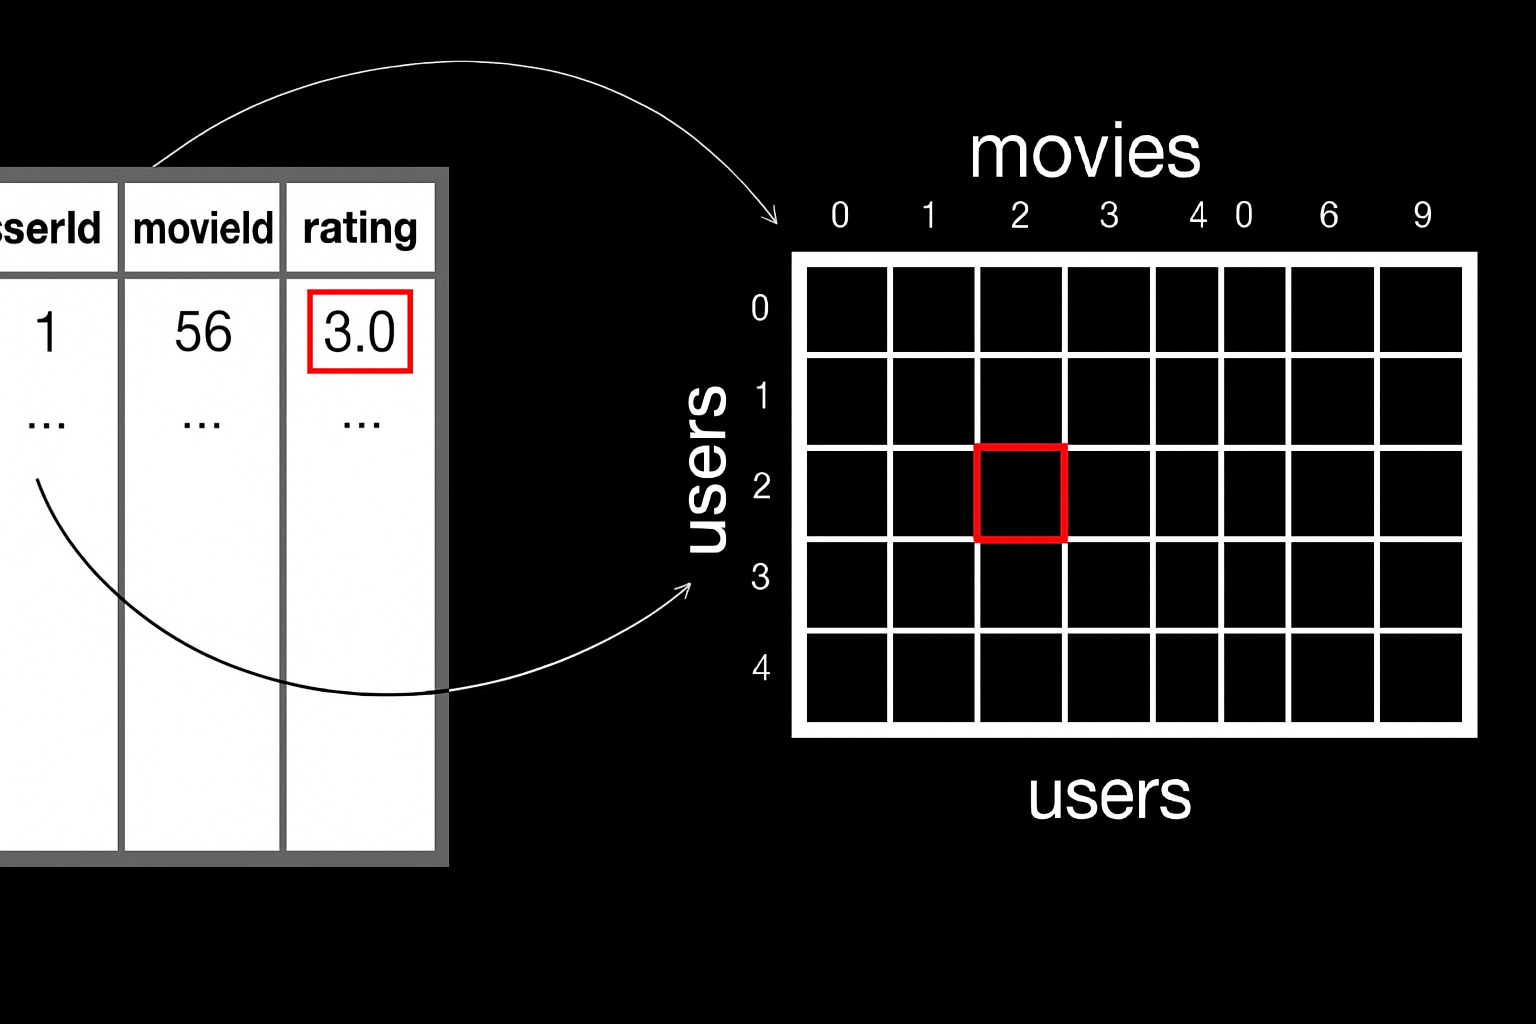

The create_X() function outputs a sparse matrix X with four mapper dictionaries:
- user_mapper: maps user id to user index
- movie-mapper: maps movie id to movie index
- user_inv_mapper: maps user index to user id
- movie_inv_mapper: maps movie index to movie id

We need these dictionaries because they map which row/collumn of the utility matrix corresponds to which user/movie id 

Our X(user-item) matrix is a 